<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Распределение классов:
 1    3690
2    4876
3     590
4      51
5     162
6     302
7     329
Name: count, dtype: int64
Лучшие параметры KNN: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.7554
Точность на тесте (KNN): 0.7580


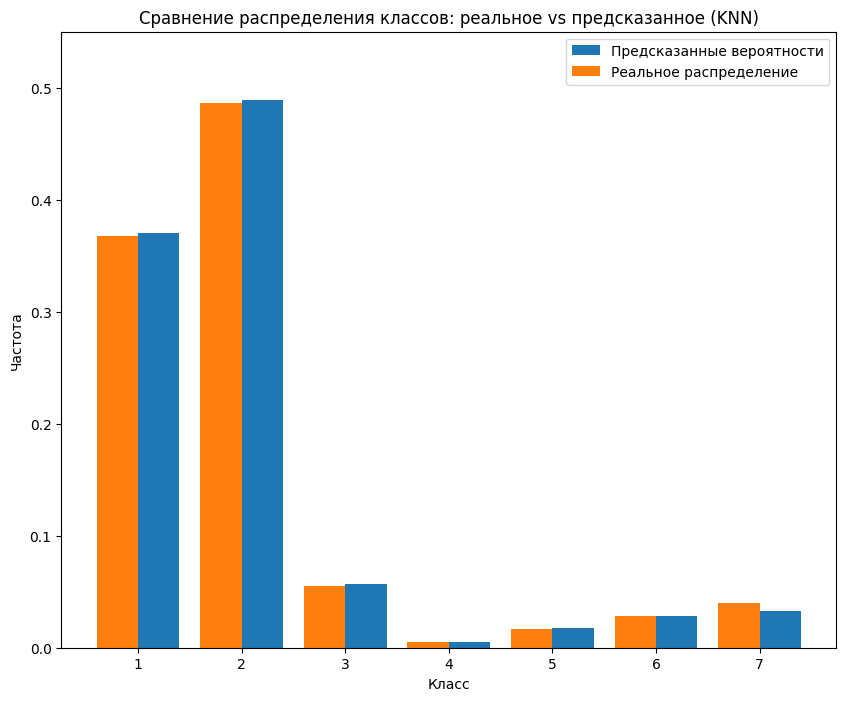

Точность на тесте (LogReg): 0.7085


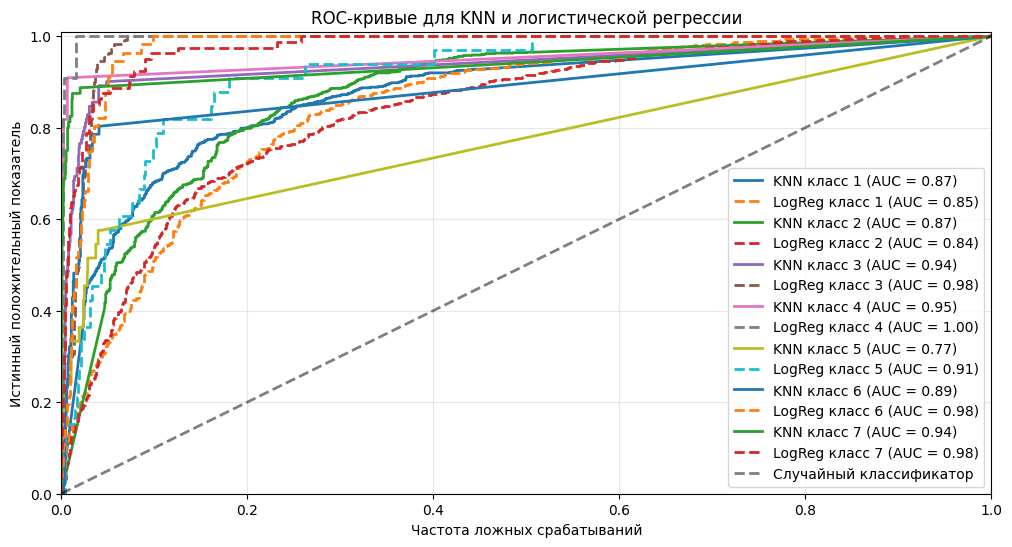


AUC-ROC (микро):
KNN: 0.9422
LogReg: 0.9584

AUC-ROC (макро):
KNN: 0.8904
LogReg: 0.9325

ВЫВОДЫ
1. Качество KNN на тесте: accuracy = 0.7580
2. Качество логистической регрессии: accuracy = 0.7085
   KNN показывает более высокую точность, чем логистическая регрессия.

3. Плюсы и минусы метода k ближайших соседей:
   Плюсы:
     - Простота реализации и интерпретации.
     - Не делает предположений о распределении данных.
     - Может работать со сложными границами классов.
   Минусы:
     - Вычислительно затратен на этапе предсказания (нужно хранить всю выборку).
     - Чувствителен к масштабу признаков и выбросам.
     - Требует выбора оптимального k и метрики расстояния.
     - Страдает от проклятия размерности (при большом числе признаков).

4. Сравнение по AUC-ROC:
   Микро-усреднение: KNN = 0.9422, LogReg = 0.9584
   Макро-усреднение: KNN = 0.8904, LogReg = 0.9325
   Логистическая регрессия имеет более высокую разделяющую способность по AUC-ROC.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

df = pd.read_csv('forest_dataset.csv', header=0)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print("Распределение классов:\n", pd.Series(y).value_counts().sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN с подбором гиперпараметров
clf = KNeighborsClassifier()
params = {
    'n_neighbors': range(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}
clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(X_train_scaled, y_train)

print("Лучшие параметры KNN:", clf_grid.best_params_)
print("Лучшая точность на кросс-валидации: {:.4f}".format(clf_grid.best_score_))

optimal_knn = clf_grid.best_estimator_
optimal_knn.fit(X_train_scaled, y_train)

y_pred_knn = optimal_knn.predict(X_test_scaled)
test_acc_knn = accuracy_score(y_test, y_pred_knn)
print("Точность на тесте (KNN): {:.4f}".format(test_acc_knn))

prob_knn = optimal_knn.predict_proba(X_test_scaled)

# Сравнение распределения классов (реальное vs предсказанное)
unique, freq_real = np.unique(y_test, return_counts=True)
freq_real = freq_real / len(y_test)

freq_pred = prob_knn.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(unique, freq_pred, width=0.4, align='edge', label='Предсказанные вероятности')
plt.bar(unique, freq_real, width=-0.4, align='edge', label='Реальное распределение')
plt.ylim(0, 0.55)
plt.xlabel("Класс")
plt.ylabel("Частота")
plt.legend()
plt.title("Сравнение распределения классов: реальное vs предсказанное (KNN)")
plt.show()

# Логистическая регрессия
#lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
from sklearn.multiclass import OneVsRestClassifier
lr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_pred_lr)
print("Точность на тесте (LogReg): {:.4f}".format(test_acc_lr))

prob_lr = lr.predict_proba(X_test_scaled)

# ROC-кривые и AUC
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 6))
for i in range(n_classes):
    fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, i], prob_knn[:, i])
    auc_knn = auc(fpr_knn, tpr_knn)
    plt.plot(fpr_knn, tpr_knn, lw=2, label=f'KNN класс {unique[i]} (AUC = {auc_knn:.2f})')

    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], prob_lr[:, i])
    auc_lr = auc(fpr_lr, tpr_lr)
    plt.plot(fpr_lr, tpr_lr, lw=2, linestyle='--', label=f'LogReg класс {unique[i]} (AUC = {auc_lr:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('Частота ложных срабатываний')
plt.ylabel('Истинный положительный показатель')
plt.title('ROC-кривые для KNN и логистической регрессии')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

micro_auc_knn = roc_auc_score(y_test_bin, prob_knn, average='micro', multi_class='ovr')
macro_auc_knn = roc_auc_score(y_test_bin, prob_knn, average='macro', multi_class='ovr')
micro_auc_lr = roc_auc_score(y_test_bin, prob_lr, average='micro', multi_class='ovr')
macro_auc_lr = roc_auc_score(y_test_bin, prob_lr, average='macro', multi_class='ovr')

print("\nAUC-ROC (микро):")
print(f"KNN: {micro_auc_knn:.4f}")
print(f"LogReg: {micro_auc_lr:.4f}")
print("\nAUC-ROC (макро):")
print(f"KNN: {macro_auc_knn:.4f}")
print(f"LogReg: {macro_auc_lr:.4f}")

# 8. Выводы
print("\n" + "="*50)
print("ВЫВОДЫ")
print("="*50)
print(f"1. Качество KNN на тесте: accuracy = {test_acc_knn:.4f}")
print(f"2. Качество логистической регрессии: accuracy = {test_acc_lr:.4f}")
if test_acc_knn > test_acc_lr:
    print("   KNN показывает более высокую точность, чем логистическая регрессия.")
elif test_acc_knn < test_acc_lr:
    print("   Логистическая регрессия показывает более высокую точность, чем KNN.")
else:
    print("   Модели показали одинаковую точность.")

print("\n3. Плюсы и минусы метода k ближайших соседей:")
print("   Плюсы:")
print("     - Простота реализации и интерпретации.")
print("     - Не делает предположений о распределении данных.")
print("     - Может работать со сложными границами классов.")
print("   Минусы:")
print("     - Вычислительно затратен на этапе предсказания (нужно хранить всю выборку).")
print("     - Чувствителен к масштабу признаков и выбросам.")
print("     - Требует выбора оптимального k и метрики расстояния.")
print("     - Страдает от проклятия размерности (при большом числе признаков).")

print("\n4. Сравнение по AUC-ROC:")
print(f"   Микро-усреднение: KNN = {micro_auc_knn:.4f}, LogReg = {micro_auc_lr:.4f}")
print(f"   Макро-усреднение: KNN = {macro_auc_knn:.4f}, LogReg = {macro_auc_lr:.4f}")
if micro_auc_knn > micro_auc_lr:
    print("   KNN имеет более высокую разделяющую способность по AUC-ROC.")
else:
    print("   Логистическая регрессия имеет более высокую разделяющую способность по AUC-ROC.")